Bring in necessary imports

In [1]:
using Revise

using LinearAlgebra
using Random
using Statistics
using Printf

using Plots

using DifferentialEquations
import StochasticDiffEq as SDE

using Optim
using Optimisers
using Optimization
using OptimizationOptimisers

using ForwardDiff
using DiffResults

using ModelingToolkit
using Symbolics
using NeuralPDE

using Lux
using LuxCUDA
using Flux

using ComponentArrays
using IntervalSets

using JLD2
using BSON

# Problem Setup
Consider a problem where there is some "thing" (such as fish, crops, etc) that grows with time that we need to strategically "harvest" to sell for a reward.

If we harvest too much, we'll set us up for failure later. If we harvest too little, we leave performance on the table.

We formulate this as the following optimal control problem:
$$
\max R = \mathbb{E}\left[ \int_{0}^{\infty} e^{- \rho t} x \left(1 - e^{- \alpha u} \right) dt \right]
$$

subject to the dynamics:
$$
dx = (r x - u) dt + \sigma x dW
$$

where $x$ represents the "thing", $u$ represents our harvesting rate (our control), $r$ represents the growth rate, $\sigma$ represents the volatility associated with the "noise" process (which is where the stochasticity enteres the system), $\rho$ represents the discount rate for the objective, and $\alpha$ represents the sensitivity of the reward to the harvesting rate.

In [2]:
# Define parameters
mutable struct Params
    α::Float64      # Reward sensitivity
    ρ::Float64      # Objective discount rate
    r::Float64      # growth rate
    σ::Float64      # volatility
    u_ctrl::Float64 # control variable (initially set to 0, will be optimized)
end

params = Params(0.5, 0.3, 0.15, 0.1, 0.0)

# Define the SDE dynamics
function drift!(du, u, p, t)
    du[1] = p.r * u[1] - p.u_ctrl
end

function diffusion!(du, u, p, t)
    du[1] = p.σ * u[1]
end

diffusion! (generic function with 1 method)

# HJB Solving
To find the optimal control, we must satisfy the HJB equation. We derive the HJB equation below.

We know the value function must satisfy:
$$
V(x) = \sup_{u_t} \mathbb{E}_{x} \left[ \int_{0}^{\infty} e^{-\rho t} x_t \left( 1 - e^{- \alpha u_t} \right) dt \right]
$$

and the associated HJB condition is given by:
$$
\rho V(x) = \max_{u} \left\{ x(1-e^{-\alpha u}) + (rx-u)V_{x}(x) + \frac{1}{2} \sigma^2 x^2 V_{xx}(x) \right\}
$$

We can solve for the optimal control by setting up the Hamiltonian:
$$
H(x,u,p) = x\left(1-e^{- \alpha u}\right) + (rx-u)V_{x}(x)
$$

and solving for $u^*$ as follows:
$$
\begin{align*}
\frac{\partial H}{\partial u} &= \alpha x e^{- \alpha u} - V_{x} = 0\\
V_x &= \alpha x e^{\alpha u^*}\\
u^*(x) &= - \frac{1}{\alpha} \ln \left( \frac{V_{x}(x)}{\alpha x} \right)
\end{align*}
$$

Substituting this back into the HJB expression:
$$
\rho V = x - \frac{V_x}{\alpha} + rx V_x + \frac{V_x}{\alpha} \ln \left( \frac{V_x}{\alpha x} \right) + \frac{1}{2} \sigma^2 x^2 V_{xx}
$$

We now explore various methods of satisfying this HJB equation in order to achieve the optimal control.

## Adaptive Dynamic Programming


We provide a basis function to approximate the form of the solution. We choose to use:
$$
V(x,\theta) = \theta_0 + \theta_1 x + \theta_2 x^2 + \theta_3 x^3
$$
as our estimated form. ADP seeks to identify the values of theta that best satisfy the HJB condition.

In [3]:
# Basis function for approximation and associated derivatives
function V(x, θ)
    return θ[1] + θ[2]*x + θ[3]*x^2 + θ[4]*x^3
end

function Vx(x, θ)
    return θ[2] + 2θ[3]*x + 3θ[4]*x^2
end

function Vxx(x, θ)
    return 2θ[3] + 6θ[4]*x
end

# Policy derived from the value function approximation
function policy(x, θ, α)
    z = Vx(x, θ)/(α*x)
    z = clamp(z, 1e-8, 0.999)

    return -(1/α)*log(z)
end

# HJB residual function to evaluate the approximation quality
function hjb_residual(x, θ, p)
    u = policy(x, θ, p.α)
    lhs = p.ρ * V(x, θ)
    rhs = x*(1-exp(-p.α*u)) + (p.r*x-u)*Vx(x, θ) + 0.5*p.σ^2*x^2*Vxx(x, θ)

    return lhs - rhs
end

# Define loss function for optimization
function loss(θ, params, xtrain)
    return mean(hjb_residual(x, θ, params)^2 for x in xtrain)
end

loss (generic function with 1 method)

Now we sample a representative state space and optimize/solve for the parameters.

In [4]:
# Sample points for training the value function approximation
xtrain = collect(range(0.1, 10.0, length=200))

# Initial guess for θ
theta_guess = [0.0, 0.1, 0.0, 0.0] # starting with linear approximation

# Optimize the parameters of the value function approximation
res = optimize(θ -> loss(θ, params, xtrain), theta_guess, BFGS())
theta_opt = Optim.minimizer(res)

4-element Vector{Float64}:
 -0.009990642130169371
  0.028212017527803075
  0.24809865575778933
 -0.007019700177859839

Now we simulate the system with the learned policy

In [5]:
mutable struct ADPParams
    α::Float64
    ρ::Float64
    r::Float64
    σ::Float64
    θ::Vector{Float64}
end

# Define the drift and diffusion functions for the ADP simulation
function drift_adp!(du, u, p, t)
    x = u[1]
    harvest = policy(x, p.θ, p.α)
    du[1] = p.r*x - harvest
    return du
end

function diffusion_adp!(du, u, p, t)
    du[1] = p.σ * u[1]
    return du
end


# Define parameters for simulation
adp_params = ADPParams(params.α, params.ρ, params.r, params.σ, theta_opt)

# Define initial condition and time span for ADP simulation
u0 = [1.0]
tspan = (0.0, 10.0)

# Simulate the system using the derived policy
prob = SDEProblem(drift_adp!, diffusion_adp!, u0, tspan, adp_params)
sol = solve(prob, SDE.EM(), dt=0.01)

retcode: Success
Interpolation: 1st order linear
t: 1001-element Vector{Float64}:
  0.0
  0.01
  0.02
  0.03
  0.04
  0.05
  0.060000000000000005
  0.07
  0.08
  0.09
  0.09999999999999999
  0.10999999999999999
  0.11999999999999998
  ⋮
  9.889999999999834
  9.899999999999833
  9.909999999999833
  9.919999999999833
  9.929999999999833
  9.939999999999833
  9.949999999999832
  9.959999999999832
  9.969999999999832
  9.979999999999832
  9.989999999999831
 10.0
u: 1001-element Vector{Vector{Float64}}:
 [1.0]
 [1.0269583117149341]
 [1.0274560651235098]
 [1.0193853433207722]
 [1.0181866115069942]
 [1.044324459412282]
 [1.0479922067266052]
 [1.0365485597116737]
 [1.0380340158124077]
 [1.0486701024804441]
 [1.07663649410577]
 [1.078102863581403]
 [1.083317798192827]
 ⋮
 [2.4730687602580694]
 [2.4438169308812143]
 [2.4426799409769497]
 [2.41617964730617]
 [2.4240339142614973]
 [2.4500534403761143]
 [2.481256754740162]
 [2.5022225527132593]
 [2.5109663684672534]
 [2.536383265114903]
 [2.5441321

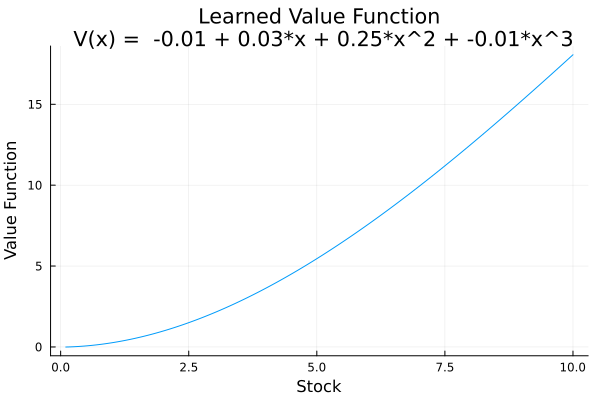

In [14]:
# Plot the learned value function approximation
xvals = collect(range(0.1, 10.0, length=200))
v_vals = [V(x, theta_opt) for x in xvals]
rounded_thetas = round.(theta_opt, digits=2)
plot(xvals, v_vals, 
    title="Learned Value Function\n $V(x) =  $(rounded_thetas[1]) + $(rounded_thetas[2])*x + $(rounded_thetas[3])*x^2 + $(rounded_thetas[4])*x^3",
    xlabel="Stock", ylabel="Value Function", legend=false)
savefig("figures/learned_value_function.png")
plot!()

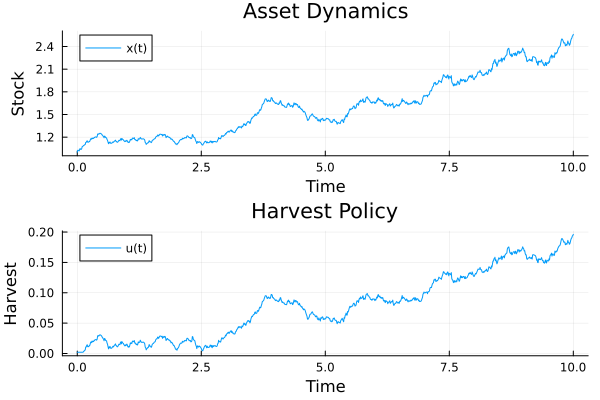

In [7]:
xvals = first.(sol.u)
uvals = [policy(x, theta_opt, adp_params.α) for x in xvals]
adp_asset_plot = plot(sol.t, xvals, title="Asset Dynamics", xlabel="Time", ylabel="Stock", label="x(t)")
adp_harvest_plot = plot(sol.t, uvals, title="Harvest Policy", xlabel="Time", ylabel="Harvest", label="u(t)")
plot(adp_asset_plot, adp_harvest_plot, layout=(2,1))

## Physics Informed Neural Network (PINN)

In [8]:
# Define milestones outside
checkpoint_milestones = [1000, 5000, 10000, 20000, 25000, 50000, 1000000]

function get_pinn_policy(x_val, weights, discretization, p)
    x = Float64(x_val)
    x_safe = max(x, 1e-4) 
    
    cpu_weights = weights |> cpu
    V_func(x_in) = first(discretization.phi([x_in], cpu_weights))
    Vx_val = ForwardDiff.derivative(V_func, x_safe)
    
    # Exact ADP Math
    z = Vx_val / (p.α * x_safe)
    z_clamped = clamp(z, 1e-8, 0.999)
    
    return -(1.0 / p.α) * log(z_clamped)
end

function hjb_res_pinn_at(x::Float64, weights, discretization, p)
    x_safe = max(x, 1e-4)
    cpu_weights = weights |> cpu
    
    Vfn(x_) = first(discretization.phi([x_], cpu_weights))
    
    Vx_val  = ForwardDiff.derivative(Vfn, x_safe)
    Vxx_val = ForwardDiff.derivative(x_ -> ForwardDiff.derivative(Vfn, x_), x_safe)
    
    # Exact ADP Math
    z = Vx_val / (p.α * x_safe)
    z_clamped = clamp(z, 1e-8, 0.999)
    u = -(1.0 / p.α) * log(z_clamped)
    
    lhs = p.ρ * Vfn(x_safe)
    rhs = x_safe * (1 - exp(-p.α * u)) + (p.r * x_safe - u) * Vx_val + 0.5 * p.σ^2 * x_safe^2 * Vxx_val
    
    # Match ADP's un-absoluted output (MSE expects raw difference)
    return lhs - rhs
end


hjb_res_pinn_at (generic function with 1 method)

In [ ]:
function run_incremental_training(params)
    r_val = Float32(params.r)
    σ_val = Float32(params.σ)
    ρ_val = Float32(params.ρ)
    α_val = Float32(params.α)
    
    x_min, x_max = 0.01f0, 10.0f0 
    
    @parameters x
    @variables V(..)
    Dx, Dxx = Differential(x), Differential(x)^2
    V_x = Dx(V(x))

    # EXACT ADP PARITY: Construct a symbolic equivalent to clamp(z, 1e-8, 0.999)
    z = V_x / (α_val * x)
    z_clamped = max(1f-8, min(0.999f0, z))
    
    u_star = -(1.0f0 / α_val) * log(z_clamped)

    # STRICT HJB EQUATION: No arbitrary gradient penalties
    lhs = ρ_val * V(x)
    rhs = x * (1.0f0 - exp(-α_val * u_star)) + (r_val * x - u_star) * V_x + 0.5f0 * σ_val^2 * x^2 * Dxx(V(x))
    eq = lhs - rhs ~ 0.0f0

    domains = [x ∈ Interval(x_min, x_max)]
    bcs = [V(x_min) ~ 0.0f0, Dx(V(x_max)) ~ 1.0f0]

    @named pde_system = PDESystem(eq, bcs, domains, [x], [V(x)])

    inner_size = 32
    chain = Lux.Chain(
        Lux.Dense(1, inner_size, Lux.tanh),
        Lux.Dense(inner_size, inner_size, Lux.tanh),
        Lux.Dense(inner_size, 1, Lux.identity) 
    )

    rng = Random.default_rng()
    ps, st = Lux.setup(rng, chain)
    ps = ComponentArray(ps) .* 0.01f0 
    ps_gpu = ps |> Lux.f32 |> gpu

    strategy = QuasiRandomTraining(500; sampling_alg = LatinHypercubeSample())
    discretization = PhysicsInformedNN(chain, strategy, init_params = ps_gpu)
    prob = discretize(pde_system, discretization)
    opt = OptimizationOptimisers.Adam(1e-4)

    total_epochs = Ref(0) 
    pinn_checkpoints = Dict{Int, Any}()
    pinn_plotting = Dict{Int, Any}() 
    loss_history = Float64[]

    cb = function (state, loss, _...)
        total_epochs[] += 1
        current_epoch = total_epochs[] 
        push!(loss_history, loss)

        if isnan(loss) || isinf(loss)
            @warn "Epoch $(current_epoch): NaN/Inf loss encountered!"
            return true 
        end

        if current_epoch in checkpoint_milestones
            println(" > Milestone reached: Epoch $(current_epoch) | Loss: $loss")
            pinn_checkpoints[current_epoch] = copy(state.u) |> cpu
        end

        if loss < 1e-5
            println(" ✓ Convergence achieved at epoch $(current_epoch)! Loss ($loss) < 1e-5. Halting.")
            pinn_checkpoints[current_epoch] = copy(state.u) |> cpu
            return true 
        end

        if current_epoch % 1000 == 0
            pinn_plotting[current_epoch] = copy(state.u) |> cpu
        end

        return false 
    end

    println("Starting PINN training analysis...")
    res = Optimization.solve(prob, opt; maxiters = checkpoint_milestones[end], callback = cb)
    return discretization, pinn_checkpoints, pinn_plotting, loss_history, res
end

# Execution
discretization, pinn_checkpoints, pinn_plotting, loss_history, res = run_incremental_training(params)


Starting PINN training analysis...
 > Milestone reached: Epoch 1000 | Loss: 16.018576
 > Milestone reached: Epoch 5000 | Loss: 2.6658657
 > Milestone reached: Epoch 10000 | Loss: 0.05691588
 > Milestone reached: Epoch 20000 | Loss: 0.0018888332
 > Milestone reached: Epoch 25000 | Loss: 0.00052911404
 > Milestone reached: Epoch 50000 | Loss: 8.091844e-5
 ✓ Convergence achieved at epoch 64214! Loss (7.5354887e-6) < 1e-5. Halting.


(PhysicsInformedNN{Lux.Chain{@NamedTuple{layer_1::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_2::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_3::Lux.Dense{typeof(identity), Int64, Int64, Nothing, Nothing, Static.True}}, Nothing}, StochasticTraining, ComponentVector{Float32, CuArray{Float32, 1, CUDACore.DeviceMemory}, Tuple{Axis{(layer_1 = ViewAxis(1:64, Axis(weight = ViewAxis(1:32, ShapedAxis((32, 1))), bias = ViewAxis(33:64, Shaped1DAxis((32,))))), layer_2 = ViewAxis(65:1120, Axis(weight = ViewAxis(1:1024, ShapedAxis((32, 32))), bias = ViewAxis(1025:1056, Shaped1DAxis((32,))))), layer_3 = ViewAxis(1121:1153, Axis(weight = ViewAxis(1:32, ShapedAxis((1, 32))), bias = ViewAxis(33:33, Shaped1DAxis((1,))))))}}}, Nothing, NeuralPDE.Phi{StatefulLuxLayer{Val{true}, Lux.Chain{@NamedTuple{layer_1::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_2::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, St

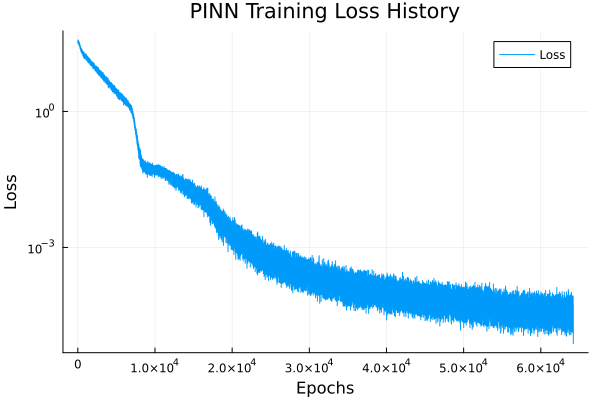

In [10]:
plot(loss_history, title="PINN Training Loss History", xlabel="Epochs", ylabel="Loss", yscale=:log10, label="Loss")
savefig("figures/pinn_training_loss_history.png")
plot!()

Epoch 1000 | Mean Absolute HJB Residual: 0.000000
Epoch 5000 | Mean Absolute HJB Residual: 0.245515
Epoch 10000 | Mean Absolute HJB Residual: 0.094159
Epoch 20000 | Mean Absolute HJB Residual: 0.009306
Epoch 25000 | Mean Absolute HJB Residual: 0.003539
Epoch 50000 | Mean Absolute HJB Residual: 0.000937
Epoch 64214 | Mean Absolute HJB Residual: 0.000443
ADP Baseline | Mean Absolute HJB Residual: 0.000864


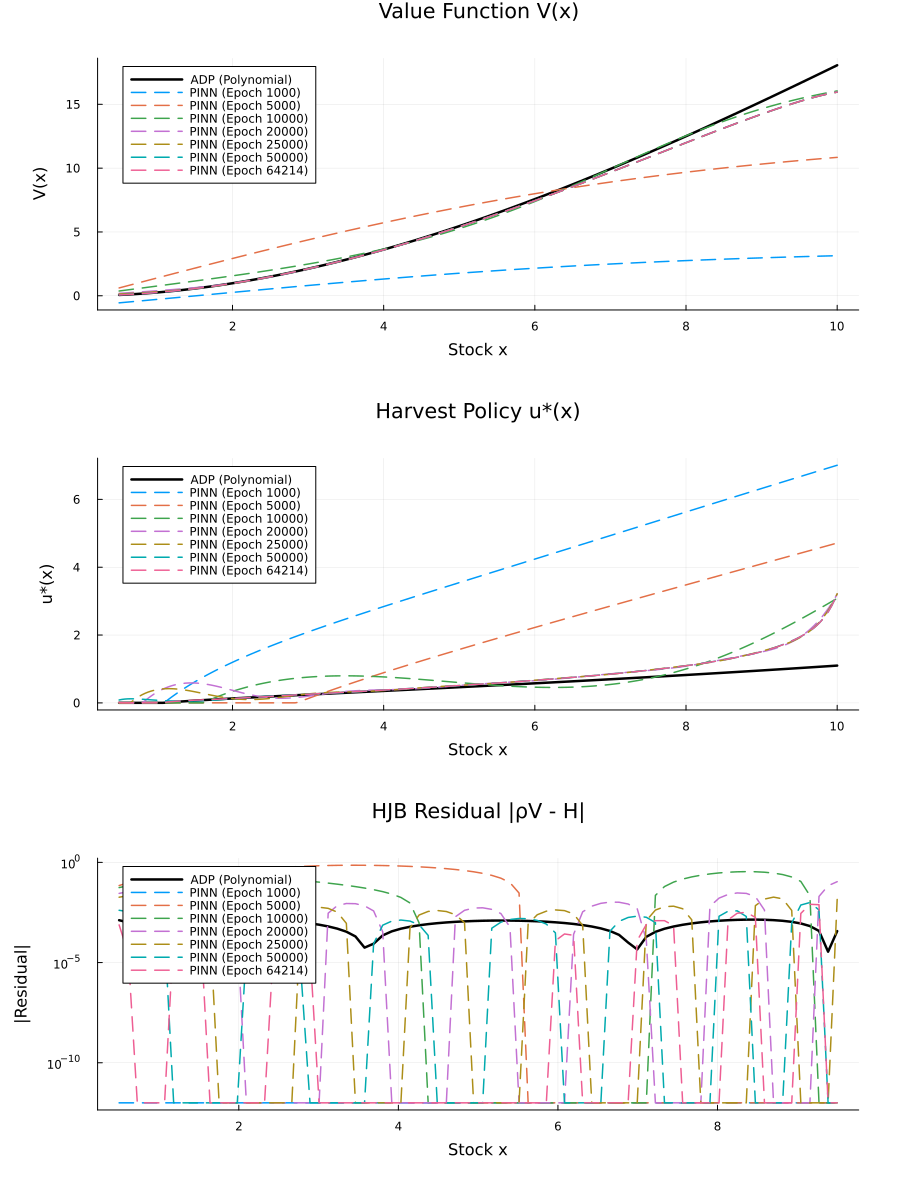

In [15]:
# Grids for plots and residual analysis
xplot_c = collect(range(0.5, 10.0, length=250))
xtest   = collect(range(0.5, 9.5, length=80))

# Build ONE fresh layout up front and plot into its subplots.
# (Combining 3 already-rendered standalone Plot objects via
# plot(p1,p2,p3,layout=...) is what triggers the
# total_plotarea_horizontal AssertionError -- each standalone plot
# already carries its own resolved bbox/margin state, and GR can
# fail to reconcile that against the new outer layout. Plotting
# directly into subplot refs of one fresh layout avoids that.)
l = @layout [a; b; c]
fig = plot(layout=l, size=(900, 1200),
           left_margin=8Plots.mm, right_margin=8Plots.mm,
           top_margin=6Plots.mm, bottom_margin=8Plots.mm)

plot!(fig[1], title="Value Function V(x)", xlabel="Stock x", ylabel="V(x)", legend=:topleft)
plot!(fig[2], title="Harvest Policy u*(x)", xlabel="Stock x", ylabel="u*(x)", legend=:topleft)
plot!(fig[3], title="HJB Residual |\u03c1V - H|", xlabel="Stock x", ylabel="|Residual|",
      legend=:topleft, yscale=:log10)

# --- Plot ADP Benchmark ---
adp_policy_fn(x) = clamp(Float64(policy(x, theta_opt, params.α)), 0.0, Inf)
# Floor away from exactly 0 so log10 never sees -Inf
adp_hjb_vec = [max(abs(hjb_residual(x, theta_opt, params)), 1e-12) for x in xtest]

plot!(fig[1], xplot_c, [V(x, theta_opt) for x in xplot_c], label="ADP (Polynomial)", lw=2.5, color=:black, ls=:solid)
plot!(fig[2], xplot_c, adp_policy_fn.(xplot_c), label="ADP (Polynomial)", lw=2.5, color=:black, ls=:solid)
plot!(fig[3], xtest, adp_hjb_vec, label="ADP (Polynomial)", lw=2.5, color=:black, ls=:solid)

# --- Plot PINN Checkpoints ---
available_epochs = sort(collect(keys(pinn_checkpoints)))

if isempty(available_epochs)
    @warn "No PINN checkpoints were stored; skipping PINN overlay plots."
else
    for (idx, epoch) in enumerate(available_epochs)
        w = pinn_checkpoints[epoch]

        # 1. Value Function
        v_vals = [Float64(first(discretization.phi([x], w))) for x in xplot_c]
        plot!(fig[1], xplot_c, v_vals, label="PINN (Epoch $epoch)", lw=1.5, color=idx, ls=:dash)

        # 2. Policy
        pol_vals = [get_pinn_policy(x, w, discretization, params) for x in xplot_c]
        plot!(fig[2], xplot_c, pol_vals, label="PINN (Epoch $epoch)", lw=1.5, color=idx, ls=:dash)

        # 3. Residuals (floored away from 0 for the log10 axis)
        res_vals = [max(hjb_res_pinn_at(x, w, discretization, params), 1e-12) for x in xtest]
        plot!(fig[3], xtest, res_vals, label="PINN (Epoch $epoch)", lw=1.5, color=idx, ls=:dash)

        # Print Mean Residual Summary to console
        mean_res = mean(res_vals)
        @printf "Epoch %4d | Mean Absolute HJB Residual: %.6f\n" epoch mean_res
    end
end

@printf "ADP Baseline | Mean Absolute HJB Residual: %.6f\n" mean(adp_hjb_vec)

savefig(fig, "figures/ADP_PINN_Comparison.png")
plot!()

[ Info: Saved animation to c:\Users\kavin\Documents\Research\generalizing_ive\notes_and_references\value_function_learning_survey\code\figures\pinn_value_convergence.gif


Plots.AnimatedGif("c:\\Users\\kavin\\Documents\\Research\\generalizing_ive\\notes_and_references\\value_function_learning_survey\\code\\figures\\pinn_value_convergence.gif")
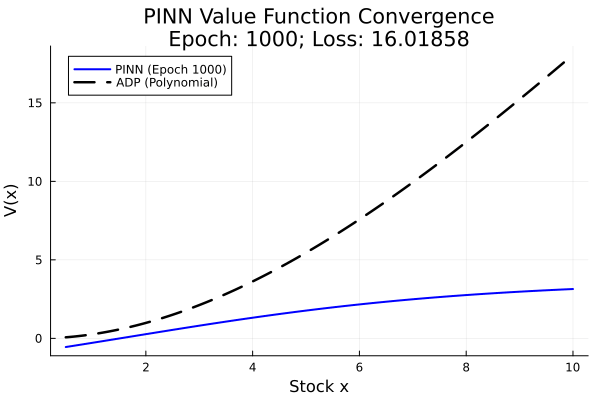

In [16]:
# Value function convergence animation
pinn_plotting_epochs = sort(collect(keys(pinn_plotting)))

value_convergence_gif = @animate for epoch in pinn_plotting_epochs
    w = pinn_plotting[epoch]
    v_vals = [Float64(first(discretization.phi([x], w))) for x in xplot_c]
    plot(xplot_c, v_vals, title="PINN Value Function Convergence\nEpoch: $epoch; Loss: $(round(loss_history[epoch], digits=5))", xlabel="Stock x", ylabel="V(x)", label="PINN (Epoch $epoch)", lw=2.0, color=:blue)
    plot!(xplot_c, [V(x, theta_opt) for x in xplot_c], label="ADP (Polynomial)", lw=2.5, color=:black, ls=:dash)
end
gif(value_convergence_gif, "figures/pinn_value_convergence.gif")

In [17]:
using JLD2

# pinn_checkpoints / pinn_plotting already contain ONLY plain, CPU-resident
# parameter arrays (each entry was stored in the training callback as
# `copy(state.u) |> cpu`), so they are safe to serialize directly --
# no anonymous functions or RuntimeGeneratedFunctions are captured here.
#
# Do NOT JLD2.save `res`, `prob`, or `discretization` as a whole: those
# objects hold the NeuralPDE/Optimization loss closures (full_loss_function,
# OptimizationFunction, RuntimeGeneratedFunction, etc.) that JLD2 can only
# store "by name" -- reloading them later will not reconstruct a working
# loss function or `phi`.

JLD2.save("pinn_checkpoints.jld2", # filename
          "pinn_checkpoints", pinn_checkpoints, # array of weights at checkpoints
          "pinn_plotting", pinn_plotting, # array of weights every 1000 epochs for convergence animation
          "loss_history", loss_history, # array of loss values per epoch
          "checkpoint_milestones", checkpoint_milestones, # list of epochs where checkpoints were saved
          "inner_size", 32,
        )   # save the architecture hyperparams you need to rebuild `chain`

println("Saved $(length(pinn_checkpoints)) PINN checkpoints to pinn_checkpoints.jld2")

# --- To reload later in a fresh session for plotting/analysis ---
# loaded = JLD2.load("pinn_checkpoints.jld2")
# pinn_checkpoints = loaded["pinn_checkpoints"]
# inner_size = loaded["inner_size"]
#
# # Rebuild the SAME architecture used in training, then just load weights in:
# chain = Lux.Chain(
#     Lux.Dense(1, inner_size, Lux.tanh),
#     Lux.Dense(inner_size, inner_size, Lux.tanh),
#     Lux.Dense(inner_size, 1, Lux.identity)
# )
# strategy = StochasticTraining(500)
# discretization = PhysicsInformedNN(chain, strategy)
# # Now discretization.phi([x], pinn_checkpoints[epoch]) works again.


Saved 7 PINN checkpoints to pinn_checkpoints.jld2


# Reload Data

In [18]:
loaded = JLD2.load("pinn_checkpoints.jld2")
pinn_checkpoints = loaded["pinn_checkpoints"]
inner_size = loaded["inner_size"]
pinn_plotting = loaded["pinn_plotting"]
loss_history = loaded["loss_history"]

# Rebuild the SAME architecture used in training, then just load weights in:
chain = Lux.Chain(
    Lux.Dense(1, inner_size, Lux.tanh),
    Lux.Dense(inner_size, inner_size, Lux.tanh),
    Lux.Dense(inner_size, 1, Lux.identity)
)
strategy = StochasticTraining(500)
discretization = PhysicsInformedNN(chain, strategy)

PhysicsInformedNN{Lux.Chain{@NamedTuple{layer_1::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_2::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_3::Lux.Dense{typeof(identity), Int64, Int64, Nothing, Nothing, Static.True}}, Nothing}, StochasticTraining, Nothing, Nothing, NeuralPDE.Phi{StatefulLuxLayer{Val{true}, Lux.Chain{@NamedTuple{layer_1::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_2::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_3::Lux.Dense{typeof(identity), Int64, Int64, Nothing, Nothing, Static.True}}, Nothing}, Nothing, @NamedTuple{layer_1::@NamedTuple{}, layer_2::@NamedTuple{}, layer_3::@NamedTuple{}}}}, typeof(NeuralPDE.numeric_derivative), Bool, Nothing, Nothing, Nothing, Base.RefValue{Int64}, Base.Pairs{Symbol, Union{}, Nothing, @NamedTuple{}}}(Lux.Chain{@NamedTuple{layer_1::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_2::Lu